## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [18]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [90]:
%pip install kneed


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [19]:
import numpy as np
import pandas as pd

In [20]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [21]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [22]:
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())

#### A3. Feature engineering

In [23]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [24]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = datetime.datetime.now().year - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [25]:
# Đặc trưng 'Dt_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], errors='coerce')
current_date = pd.Timestamp.now().normalize()
customer_data['Enroll_days'] = (current_date - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [26]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map).fillna(1)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [27]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
accepted_cols = [f'AcceptedCmp{i}' for i in range(1, 6)]
customer_data['Num_Accepted'] = customer_data[accepted_cols].sum(axis=1)

In [28]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_data['MntTotal'] = customer_data[mnt_cols].sum(axis=1)

#### A4. Phân tích EDA

In [29]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,916,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,916.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-01 05:36:25.152838656,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196,4847.766376,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000,4325.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-05 18:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000,4686.000000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-01 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000,4847.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-10 00:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000,5024.250000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000,5388.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,269.524649,0.906959,0.678381,602.249288


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

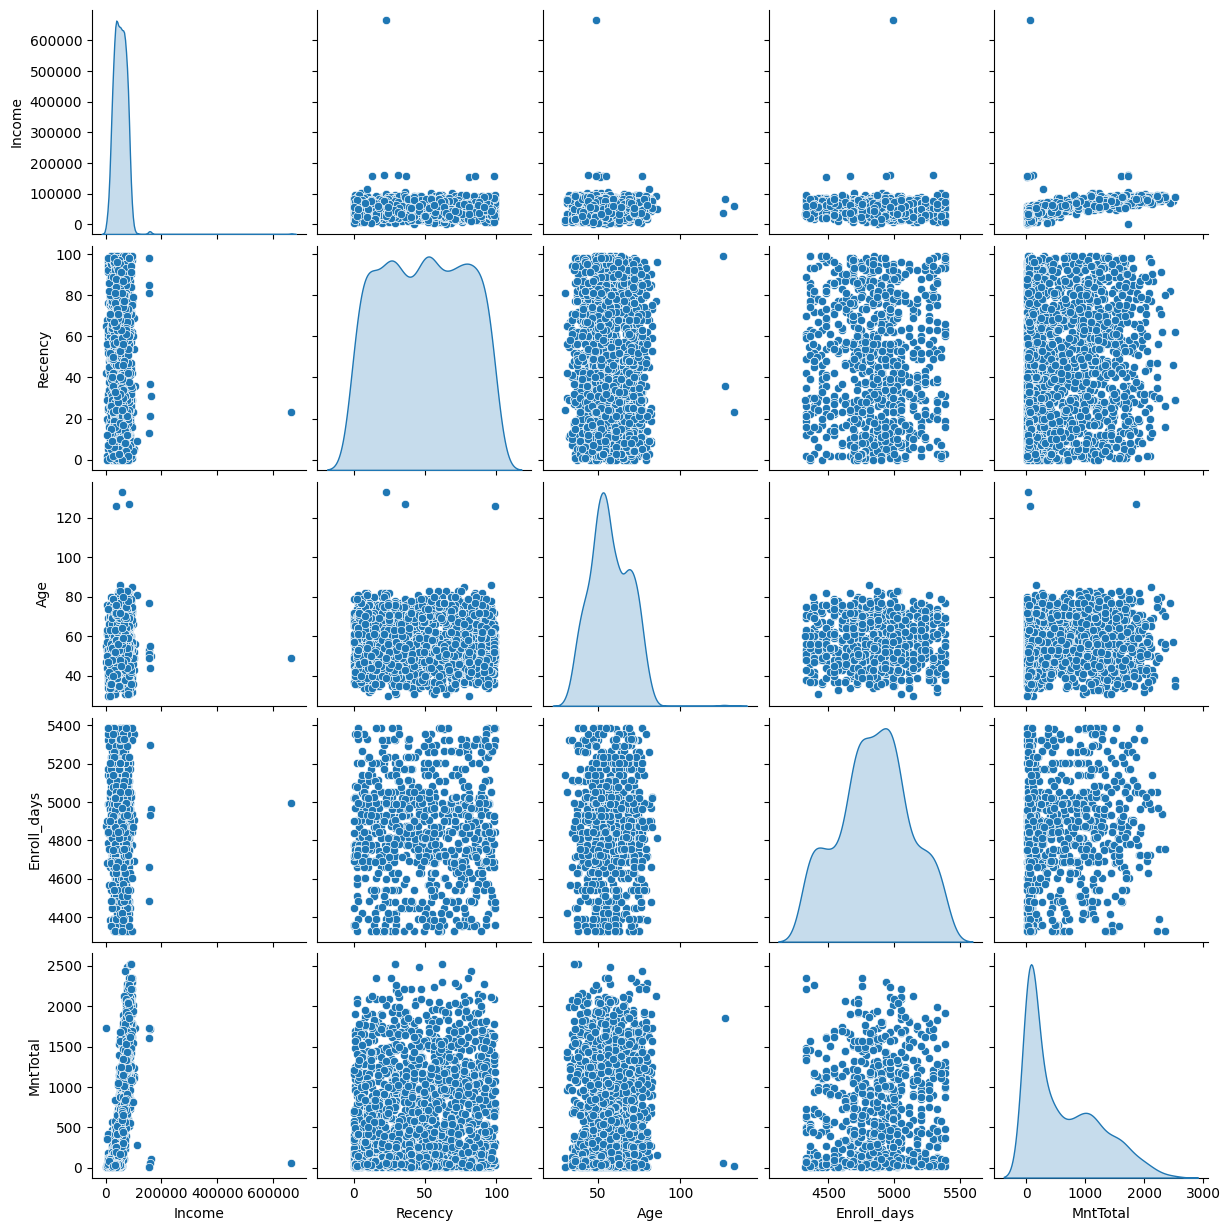

In [31]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
sns.pairplot(customer_data[plot_cols], diag_kind='kde', height=2.5)
plt.show()

In [32]:
for col in ['Income', 'MntTotal', 'Age', 'Enroll_days']:
    q_low = customer_data[col].quantile(0.01)
    q_high = customer_data[col].quantile(0.99)
    customer_data[col] = customer_data[col].clip(lower=q_low, upper=q_high)

In [33]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [34]:
# Mã hoá thuộc tính phân loại
# Giữ lại cột Education để chuyển thành one-hot encoding
# và loại bỏ các cột không cần thiết cho clustering
df = customer_data.copy()
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Num_Accepted'
], axis=1, inplace=True)

df = pd.get_dummies(df, columns=['Education'], drop_first=False)
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
ID,,,,,,,,,,,,,,,,
5524,58138.0,58,3,8,10,4,7,69,5296.0,1,1617,False,False,True,False,False
2174,46344.0,38,2,1,1,2,5,72,4450.0,3,27,False,False,True,False,False
4141,71613.0,26,1,8,2,10,4,61,NaN,2,776,False,False,True,False,False
6182,26646.0,26,2,2,0,4,6,42,4390.0,3,53,False,False,True,False,False
5324,58293.0,94,5,5,3,6,5,45,NaN,3,422,False,False,False,False,True


**Chuẩn hoá các thuộc tính kiểu số**

In [35]:
# Chuẩn hóa các thuộc tính kiểu số
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [36]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,9.160000e+02,2.240000e+03,2.240000e+03
mean,2.331468e-16,-3.172066e-18,-9.833404e-17,-5.709718e-17,9.516197e-18,7.612958e-17,-6.344132e-17,-2.260097e-16,1.628974e-15,-7.612958e-17,-7.771561e-17
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000546e+00,1.000223e+00,1.000223e+00
min,-2.138358e+00,-1.696001e+00,-1.203537e+00,-1.470368e+00,-9.108985e-01,-1.781466e+00,-2.191381e+00,-1.983295e+00,-1.937076e+00,-1.759115e+00,-9.897001e-01
25%,-7.878744e-01,-8.671566e-01,-6.858866e-01,-7.504503e-01,-9.108985e-01,-8.584551e-01,-9.548307e-01,-6.972307e-01,-6.005366e-01,-6.562832e-01,-8.963508e-01
50%,-1.696875e-03,-3.777284e-03,-1.682363e-01,-3.053224e-02,-2.265407e-01,-2.431145e-01,2.817201e-01,-9.706725e-02,-9.504439e-04,4.465483e-01,-3.483950e-01
75%,8.012448e-01,8.596020e-01,3.494139e-01,6.893858e-01,4.578170e-01,6.798964e-01,6.939037e-01,8.460467e-01,6.552530e-01,4.465483e-01,7.391447e-01
max,2.069975e+00,1.722981e+00,6.561217e+00,8.248526e+00,8.670110e+00,2.218248e+00,6.052291e+00,2.046373e+00,1.997732e+00,2.652211e+00,2.548362e+00


#### A6. Phân cụm KMeans

In [37]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

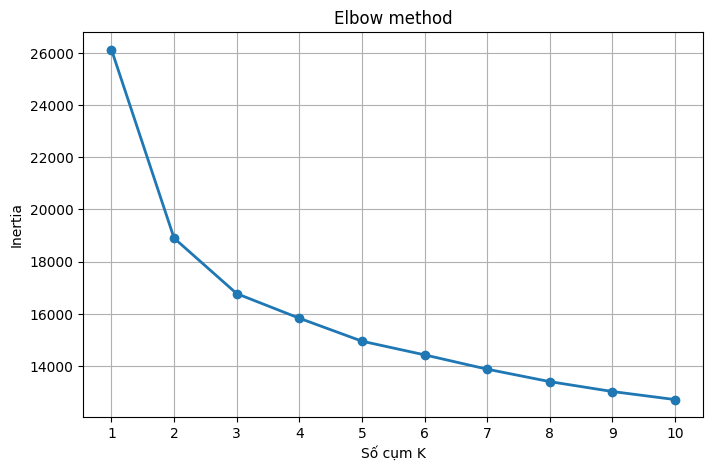

In [41]:
# Tính inertia cho từng K để xác định điểm gãy elbow
# Đảm bảo không còn NaN trước khi fit KMeans
customer_data = customer_data.copy()
for col in customer_data.select_dtypes(include=[np.number]).columns:
    customer_data[col] = customer_data[col].fillna(customer_data[col].mean())

# Tiếp tục với dữ liệu đã xử lý cho clustering
processed_df = customer_data.copy()
processed_df = processed_df.drop(columns=['Dt_Customer', 'Year_Birth', 'Kidhome', 'Teenhome', 'Marital_Status',
                                          'Z_CostContact', 'Z_Revenue', 'MntWines', 'MntFruits',
                                          'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
                                          'MntGoldProds', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                                          'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response',
                                          'Num_Accepted'])
processed_df = pd.get_dummies(processed_df, columns=['Education'], drop_first=False)
num_cols = processed_df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
processed_df[num_cols] = scaler.fit_transform(processed_df[num_cols])

inertia_values = []
ks = list(range(1, 11))

for k in ks:
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    model.fit(processed_df)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia_values, marker='o', color='tab:blue', linewidth=2)
plt.xlabel('Số cụm K')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.xticks(ks)
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [44]:
%pip install yellowbrick

     ------------------------------------ 282.6/282.6 kB 870.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from yellowbrick.cluster import KElbowVisualizer

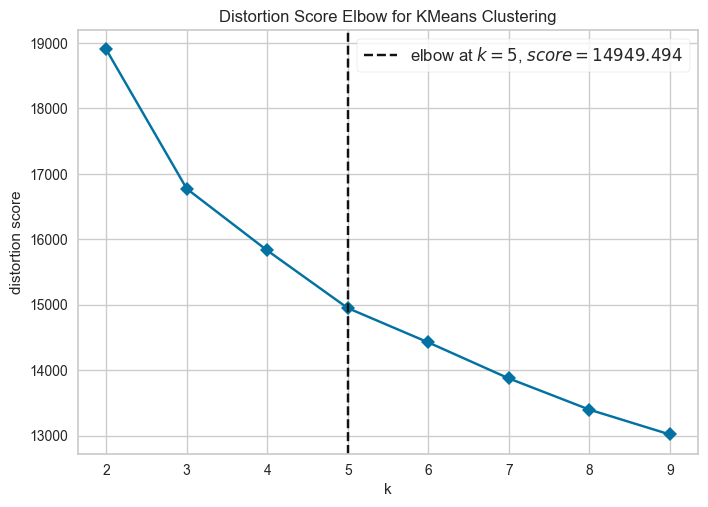

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [47]:
# Dùng dữ liệu đã làm sạch và chuẩn hóa để ước lượng K
visualizer = KElbowVisualizer(
    KMeans(n_init=20, random_state=42),
    k=(2, 10),
    timings=False
)
visualizer.fit(processed_df)
visualizer.show()

**Phân cụm từ kết quả của phương pháp Elbow**

In [51]:
k = 4
kmean = KMeans(n_clusters=k, n_init=20, random_state=42)
kmean.fit(processed_df)

kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,5296.000000,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4450.000000,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,NaT,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4847.756004,2,0,776,3
6182,1984,Graduation,2,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4390.000000,3,0,53,0
5324,1981,PhD,2,58293.0,1,0,NaT,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4847.756004,3,0,422,2


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [52]:
from sklearn.decomposition import PCA

In [53]:
pca = PCA(n_components=2)
scores = pca.fit_transform(processed_df)
print('Kiểm tra tỷ lệ phương sai giải thích:', np.round(pca.explained_variance_ratio_.sum(), 4))

Kiểm tra tỷ lệ phương sai giải thích: 0.4882


**Trực quan hoá kết quả phân cụm**

In [54]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    fig, ax = plt.subplots(figsize=(8,8))
    sns.scatterplot(
        x=scores[:,0],
        y=scores[:,1],
        hue=labels,
        palette='Set1',
        legend='full',
        ax=ax
    )
    ax.set_title('KMeans clustering result on 2D PCA space')
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [55]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,5296.000000,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4450.000000,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,NaT,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4847.756004,2,0,776,3
6182,1984,Graduation,2,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4390.000000,3,0,53,0
5324,1981,PhD,2,58293.0,1,0,NaT,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4847.756004,3,0,422,2


In [56]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

In [57]:
# visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

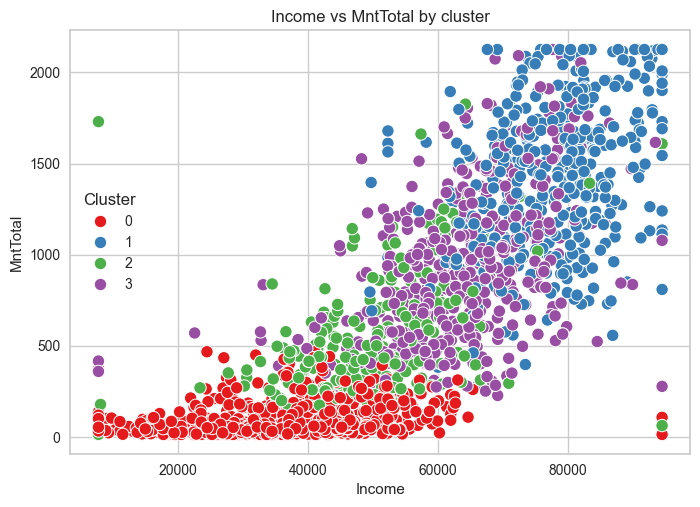

In [58]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
sns.scatterplot(
    data=kmean_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Income vs MntTotal by cluster')
plt.show()

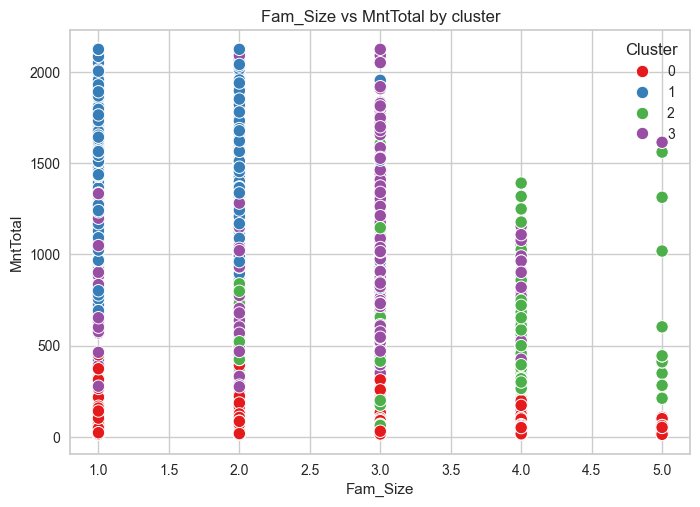

In [59]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
sns.scatterplot(
    data=kmean_df,
    x='Fam_Size',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Fam_Size vs MntTotal by cluster')
plt.show()

**Phân tích danh mục mua hàng**

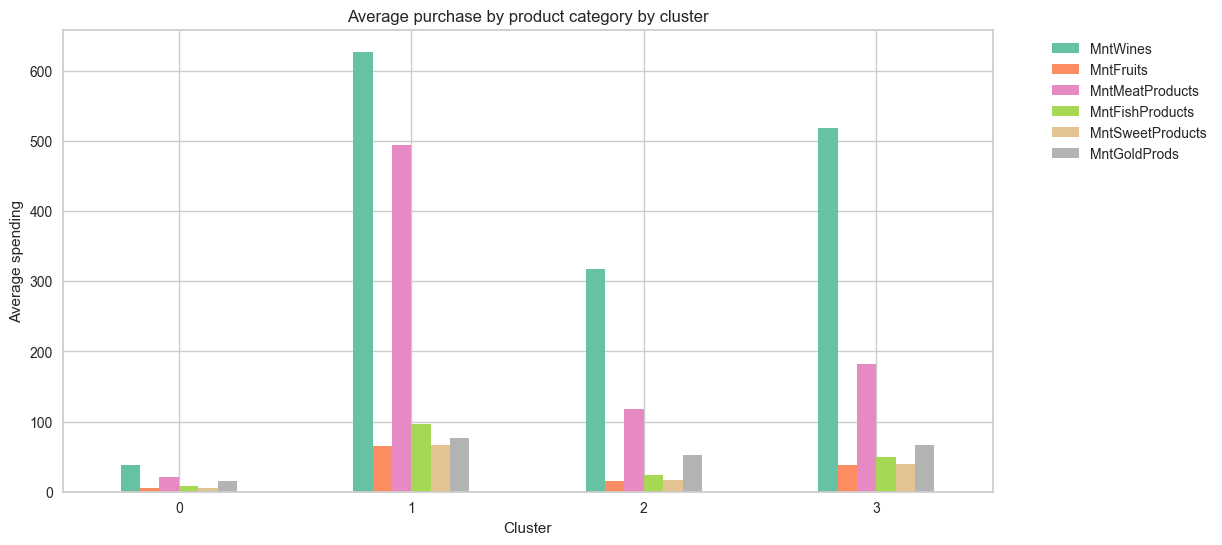

In [60]:
# Phân tích danh mục mua hàng theo cụm
purchase_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_purchase = kmean_df.groupby('Cluster')[purchase_cols].mean()
cluster_purchase.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Average purchase by product category by cluster')
plt.ylabel('Average spending')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

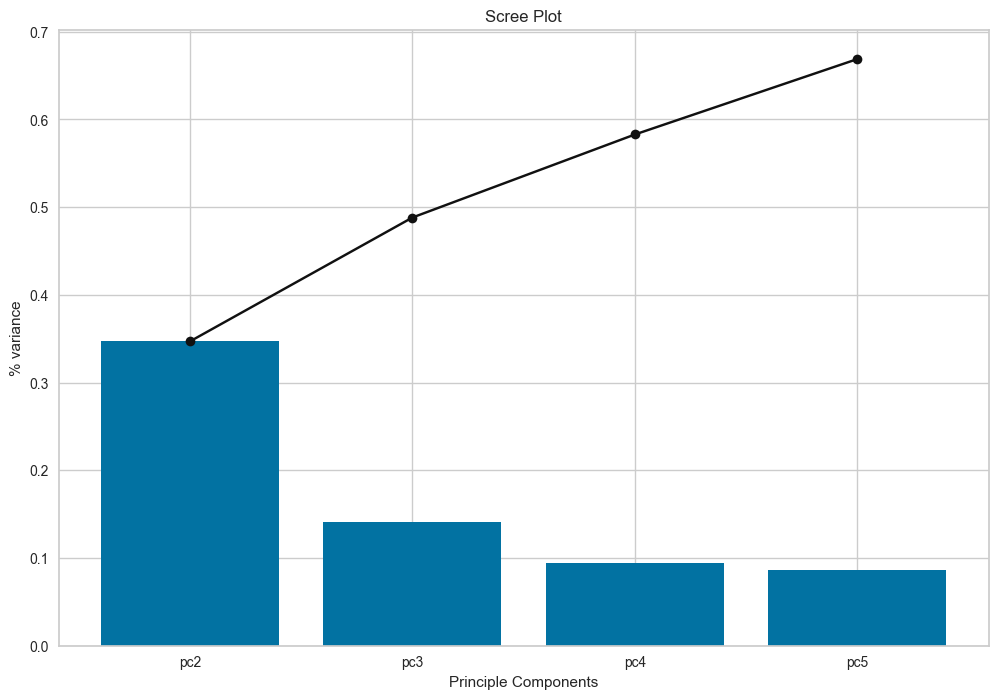

In [72]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    if not hasattr(pca_model, 'explained_variance_ratio_'):
        pca_model.fit(processed_df)

    fig, ax = plt.subplots(figsize=(12, 8))

    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)

    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')

    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')

    plt.grid(True)
    plt.show()

# Fit PCA trước khi vẽ scree plot
pca = PCA(n_components=min(4, processed_df.shape[1]))
pca.fit(processed_df)
scree_plot(pca, [f'pc{i+1}' for i in range(1, len(pca.explained_variance_ratio_) + 1)])

In [68]:
# biến đổi processed_df sang không gian pca 4 chiều
pca = PCA(n_components=4)
pca_transformed_4d = pca.fit_transform(processed_df)
print('Explained variance ratio cumulative:', np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio cumulative: [0.34696703 0.48822032 0.58290567 0.6689043 ]


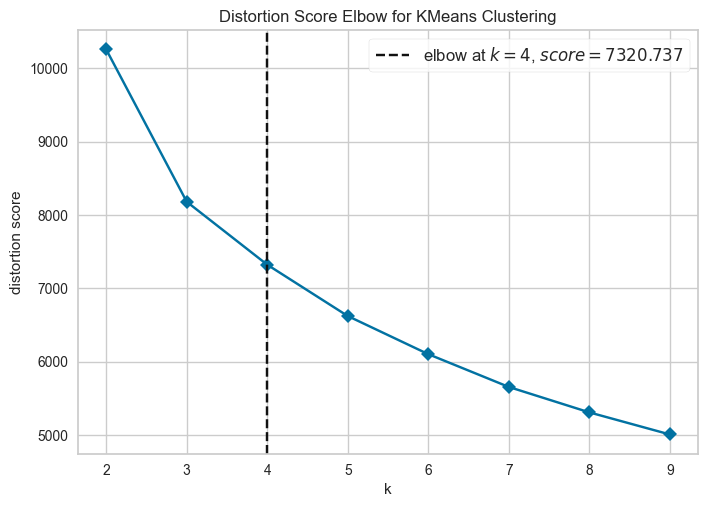

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [69]:
model = KMeans(n_clusters=4, n_init=20, random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 10), timings=False)
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [70]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
pca_kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
pca_kmeans.fit(pca_transformed_4d)

kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = pca_kmeans.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,5296.000000,1,0,1617,3
2174,1954,Graduation,1,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4450.000000,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,NaT,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4847.756004,2,0,776,3
6182,1984,Graduation,2,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4390.000000,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,NaT,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4847.756004,3,0,422,0


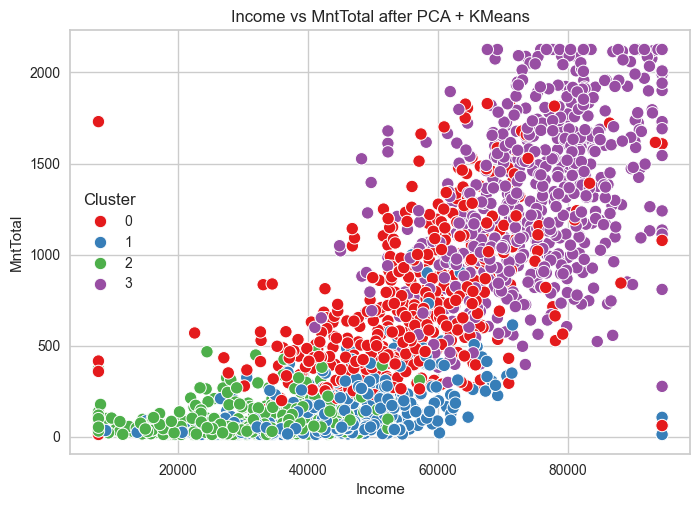

In [71]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
sns.scatterplot(
    data=kmean_pca_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Income vs MntTotal after PCA + KMeans')
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [73]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [74]:
len(df.columns)

16

In [75]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [76]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [77]:
import pandas as pd

In [83]:
df = pd.read_csv('data/taxi_data.csv')
df = df.dropna(subset=['LAT', 'LON']).reset_index(drop=True)
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [80]:
%pip install folium

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ------------------------------------ 113.4/113.4 kB 946.4 kB/s eta 0:00:00
     ---------------------------------------- 73.1/73.1 kB ? eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 98.8/98.8 kB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 69.6/69.6 kB 3.7 MB/s eta 0:00:00
     -------------------------------------- 215.4/215.4 kB 2.2 MB/s eta 0:00:00
     -------------------------------------- 137.0/137.0 kB 2.7 MB/s eta 0:00:00
     ------------------------------------ 135.7/135.7 kB 889.9 kB/s eta 0:00:00


In [91]:
import folium
import re

In [96]:
X = df[['LAT', 'LON']].dropna().to_numpy()
if X.size == 0:
    raise ValueError('Taxi dataset does not contain valid LAT/LON values after cleaning.')

map_center = [float(X[:, 0].mean()), float(X[:, 1].mean())]
m = folium.Map(
    location=map_center,
    tiles='OpenStreetMap',
    zoom_start=10
)

In [97]:
for _, row in df.iterrows():
    popup_text = re.sub(r'\W+', ' ', str(row.get('NAME', ''))).strip()
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=5,
        popup=popup_text or 'Taxi stop',
        fill=True,
        color='blue',
        fill_color='blue',
        fill_opacity=0.8
    ).add_to(m)

# Thêm tiêu đề cho bản đồ
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

In [ ]:
# Knee plot để ước lượng eps
X_scaled = StandardScaler().fit_transform(X)
selected_distances = knee_plot(10, X_scaled)
print('Khoảng cách k-th gần nhất (mẫu):', np.quantile(selected_distances, [0.5, 0.75, 0.9, 0.95]))

In [ ]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [ ]:
# Sử dụng DBSCAN để phân cụm
X_scaled = StandardScaler().fit_transform(X)
# chọn eps ở điểm gãy của k-distance plot
selected_distances = knee_plot(10, X_scaled)
eps = np.quantile(selected_distances, 0.9)
db = DBSCAN(eps=eps, min_samples=10)
df['cluster'] = db.fit_predict(X_scaled)

cluster_ids = sorted(df['cluster'].unique())
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 'olive', 'goldenrod', 'navy', 'crimson']
color_map = {-1: 'black'}
for idx, cid in enumerate(cluster_ids):
    if cid != -1:
        color_map[cid] = colors[idx % len(colors)]
df['cluster_color'] = df['cluster'].map(color_map)

m = create_map('cluster', 'cluster_color', 'Taxi clusters from DBSCAN')
m

In [ ]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m